# 03_IBD_GTstudentproject_train

This dataset associate OPs to their Biological Diatom Index (IBD; Prygiel & Coste, 2000) value, a index of river ecological quality estimated from inventories composition.

The file contains the following columns:

-   *SamplingOperations_code*: code of the diatom sampling operation.

-   *IBD*: raw IBD value. This value ranges from 0 (lowest ecological quality) to 20 (maximum ecological quality).

-   *IBD_EQR*: *Ecological quality ratio* of the IBD, computed from the raw IBD value and from thresholds specific to the hydroecoregion (HER) to which the OP site belongs. Details in French about the computation of these values can be found here (section 1.1.2.1): <https://www.legifrance.gouv.fr/jorf/id/JORFARTI000037347765>

-   *IBD_EQR_Status*: ecological quality status (*Bad*, *Poor*, *Moderate*, *Good* or *High*) estimated from the value of *IBD_EQR*.


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set(style="ticks", context="notebook", palette="deep")
pd.set_option('display.max_columns', None)

In [3]:
path = "../../data/raw/"
dfs = {}

# read all dataframes and keep them in dfs
for parquet in os.listdir(path):  # List all files in the directory
    if parquet.endswith(".parquet"):
        name = parquet.split(".parquet")[0]  # Get name without extension
        dfs[name] = pd.read_parquet(os.path.join(path, parquet))  # Use os.path.join for paths
        print(f"Loaded {name} with shape {dfs[name].shape}")

Loaded 01_DiatomInventories_GTstudentproject_B with shape (1643872, 8)
Loaded 02_InfoSites_GTstudentproject_B with shape (8404, 11)
Loaded 03_IBD_GTstudentproject_test with shape (5063, 2)
Loaded 03_IBD_GTstudentproject_train with shape (43783, 4)
Loaded 04_PressureStatus_GTstudentproject_B with shape (49231, 30)
Loaded 05_EnvParamMeans_GTstudentproject_B with shape (3763903, 8)
Loaded 06_ListEnvParam_GNNprojectGT_B with shape (192, 14)
Loaded 07_TaxaCode_GTstudentproject_B with shape (2292, 2)


In [4]:
df = dfs[list(dfs.keys())[3]] 
df

,SamplingOperations_code,IBD,IBD_EQR,IBD_EQR_Status
0,S04319000_20130724,5.2,0.256098,Bad
1,S06172100_20080716,6.1,0.298246,Bad
2,S03255920_20120802,3.7,0.157895,Bad
3,S04064720_20150710,4.9,0.228070,Bad
4,S05001500_20080726,5.3,0.251462,Bad
...,...,...,...,...
43778,S06165700_20230628,6.8,0.339181,Poor
43779,S06440770_20230524,15.3,0.836257,Good
43780,S06710030_20230627,18.4,1.000000,High
43781,S06036970_20230628,14.5,0.678571,Moderate


In [5]:
df.head()

,SamplingOperations_code,IBD,IBD_EQR,IBD_EQR_Status
0,S04319000_20130724,5.2,0.256098,Bad
1,S06172100_20080716,6.1,0.298246,Bad
2,S03255920_20120802,3.7,0.157895,Bad
3,S04064720_20150710,4.9,0.228070,Bad
4,S05001500_20080726,5.3,0.251462,Bad


In [6]:
dfs[list(dfs.keys())[3]].nunique()

SamplingOperations_code    43573
IBD                          167
IBD_EQR                      605
IBD_EQR_Status                 5
dtype: int64

Text(0.5, 0, 'IBD_EQR')

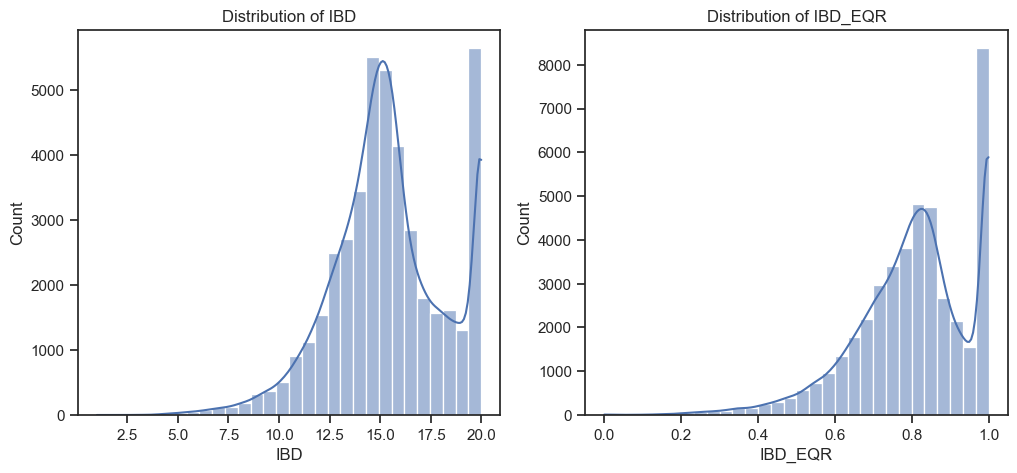

In [7]:
# distributions of IBD and IBD_EQR
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['IBD'], kde=True, bins=30)
plt.title('Distribution of IBD')
plt.xlabel('IBD')
plt.subplot(1, 2, 2)
sns.histplot(df['IBD_EQR'], kde=True, bins=30)
plt.title('Distribution of IBD_EQR')
plt.xlabel('IBD_EQR')

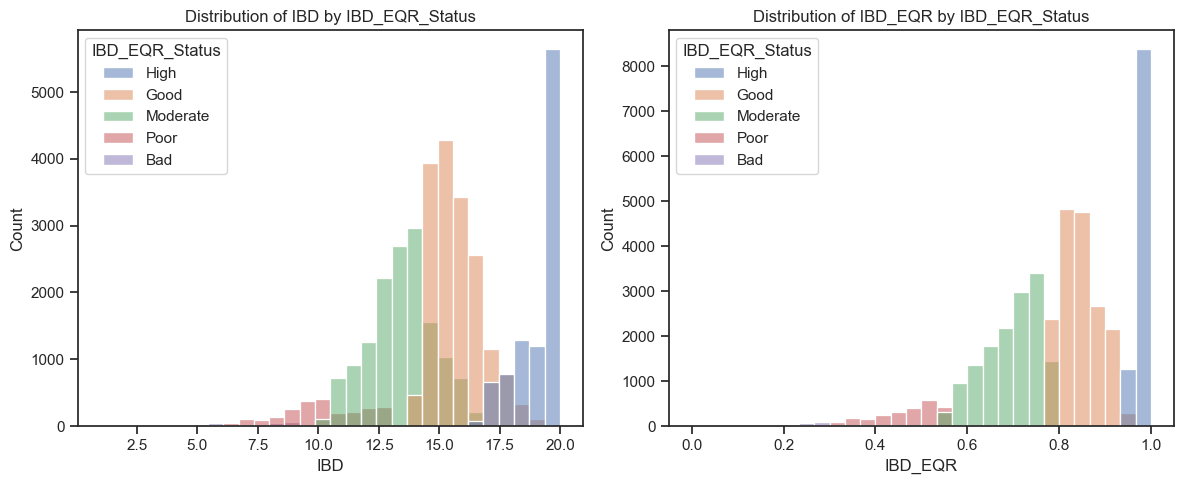

In [8]:
status_order = ['High', 'Good', 'Moderate', 'Poor', 'Bad']

# distributions of IBD and IBD_EQR classified by IBD_EQR_Status
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df, x='IBD', bins=30, hue='IBD_EQR_Status', hue_order=status_order)
plt.title('Distribution of IBD by IBD_EQR_Status')
plt.xlabel('IBD')
plt.subplot(1, 2, 2)
sns.histplot(df, x='IBD_EQR', bins=30, hue='IBD_EQR_Status', hue_order=status_order)
plt.title('Distribution of IBD_EQR by IBD_EQR_Status')
plt.xlabel('IBD_EQR')
plt.tight_layout()

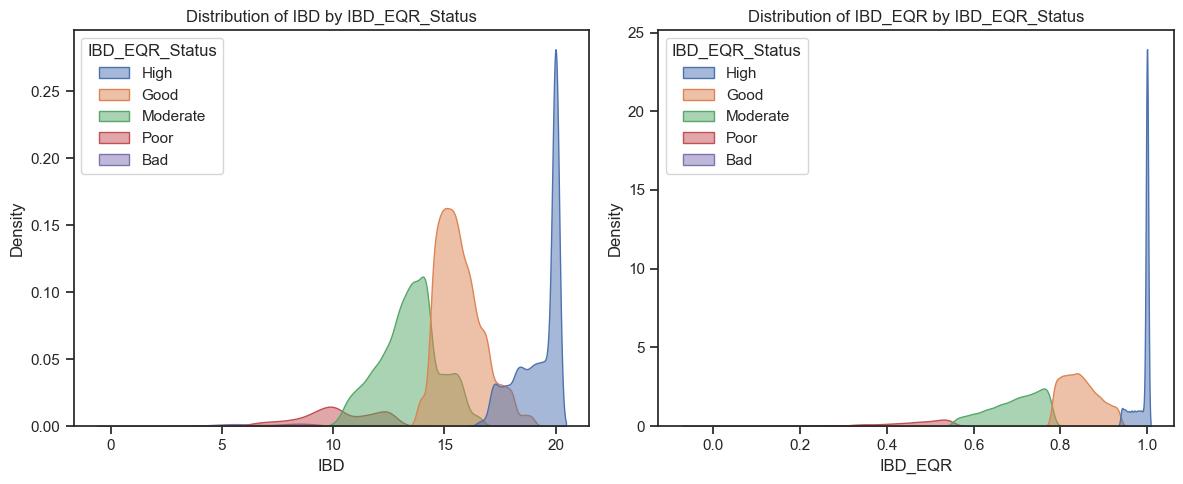

In [9]:
# distributions of IBD and IBD_EQR classified by IBD_EQR_Status
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.kdeplot(data=df, x='IBD', hue='IBD_EQR_Status', hue_order=status_order, fill=True, alpha=0.5)
plt.title('Distribution of IBD by IBD_EQR_Status')
plt.xlabel('IBD')
plt.subplot(1, 2, 2)
sns.kdeplot(data=df, x='IBD_EQR', hue='IBD_EQR_Status', hue_order=status_order, fill=True, alpha=0.5)
plt.title('Distribution of IBD_EQR by IBD_EQR_Status')
plt.xlabel('IBD_EQR')
plt.tight_layout()

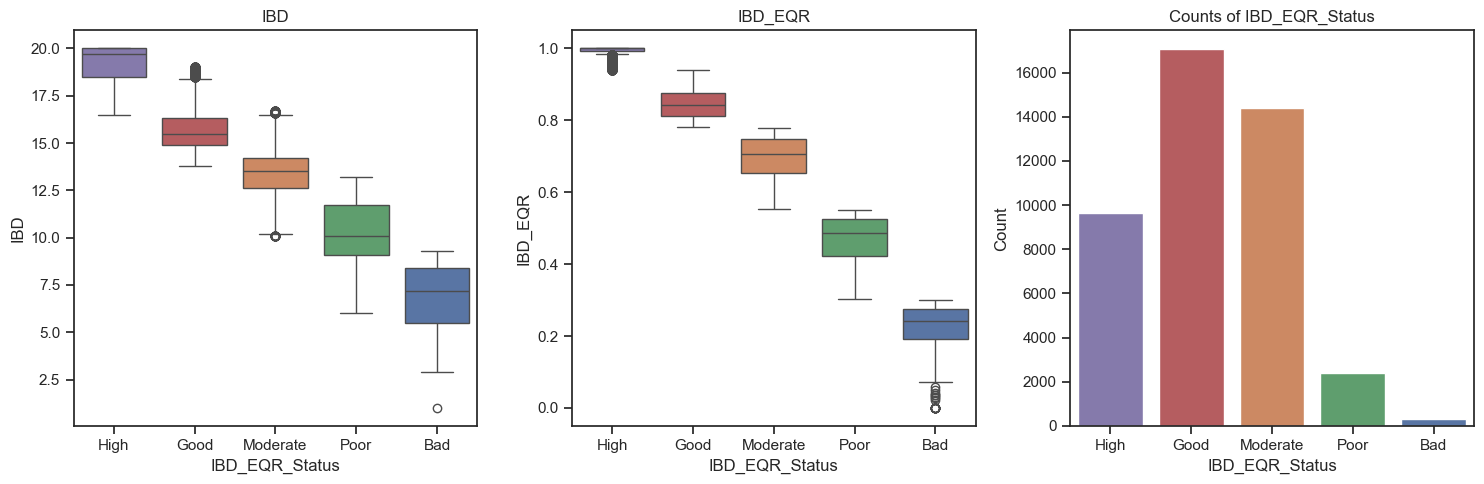

In [10]:
plt.figure(figsize=(15, 5))

# Plot boxplots for each variable
for i, column in enumerate(['IBD', 'IBD_EQR'], 1):
    plt.subplot(1, 3, i)
    sns.boxplot(data=df, x='IBD_EQR_Status', y=column, order=status_order, hue='IBD_EQR_Status')
    plt.title(f'{column}')
    plt.xlabel('IBD_EQR_Status')
    plt.ylabel(column)

# Add a count plot for IBD_EQR_Status
plt.subplot(1, 3, 3)
sns.countplot(data=df, x='IBD_EQR_Status', order=status_order, hue='IBD_EQR_Status')
plt.title('Counts of IBD_EQR_Status')
plt.xlabel('IBD_EQR_Status')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

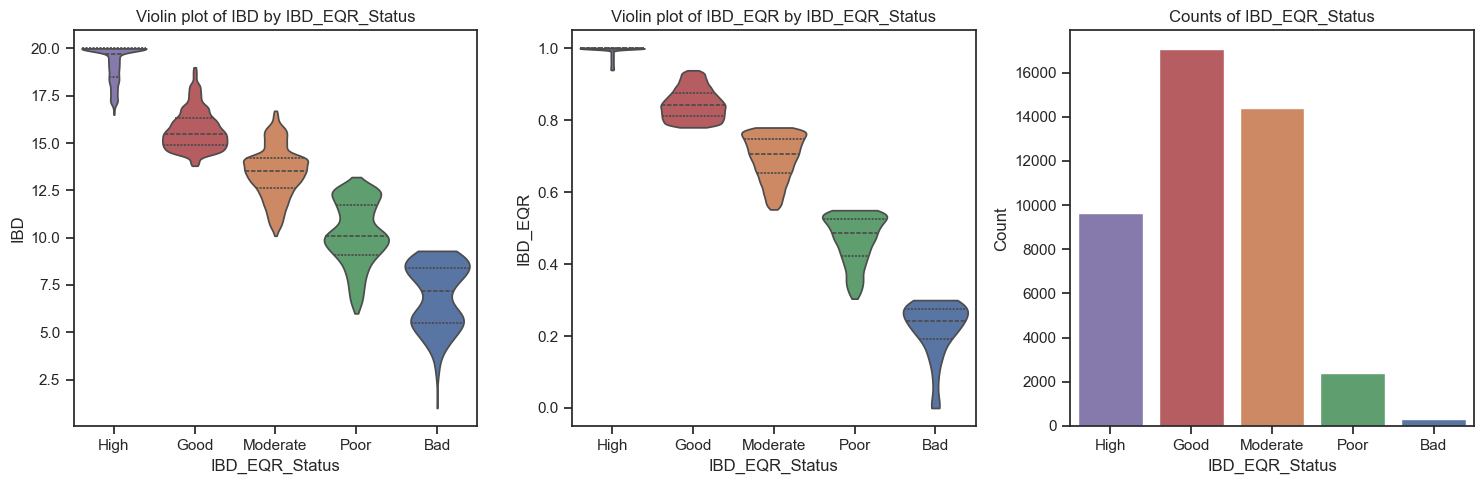

In [11]:
plt.figure(figsize=(15, 5))

# Plot violin plots for each variable
for i, column in enumerate(['IBD', 'IBD_EQR'], 1):
    plt.subplot(1, 3, i)
    sns.violinplot(data=df, x='IBD_EQR_Status', y=column, order=status_order, cut=0, inner='quartile', hue='IBD_EQR_Status')
    plt.title(f'Violin plot of {column} by IBD_EQR_Status')
    plt.xlabel('IBD_EQR_Status')
    plt.ylabel(column)

# Add a count plot for IBD_EQR_Status
plt.subplot(1, 3, 3)
sns.countplot(data=df, x='IBD_EQR_Status', order=status_order, hue='IBD_EQR_Status')
plt.title('Counts of IBD_EQR_Status')
plt.xlabel('IBD_EQR_Status')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

<Figure size 1000x1000 with 0 Axes>

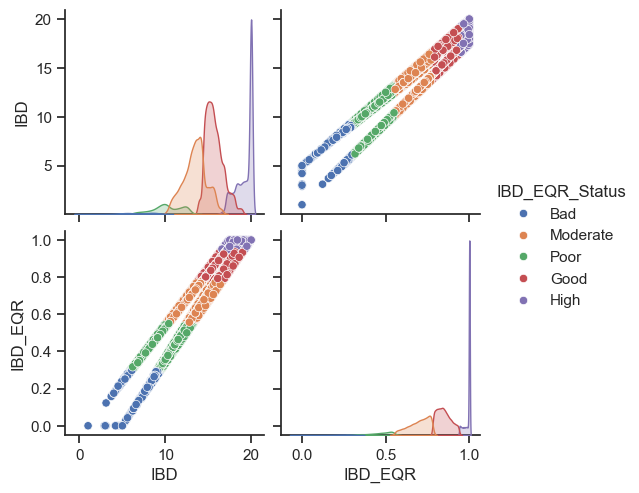

In [12]:
plt.figure(figsize=(10, 10))
sns.pairplot(df[['IBD', 'IBD_EQR', 'IBD_EQR_Status']], hue='IBD_EQR_Status')
plt.show()

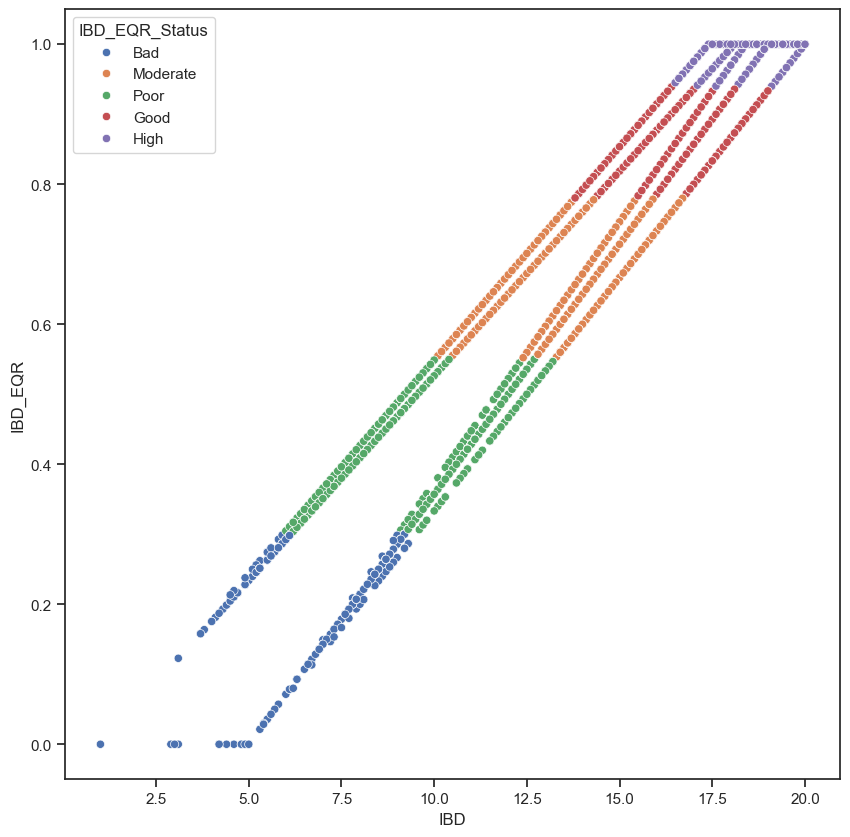

In [13]:
plt.figure(figsize=(10, 10))
sns.scatterplot(data=df, x='IBD', y='IBD_EQR', hue='IBD_EQR_Status')
plt.show()

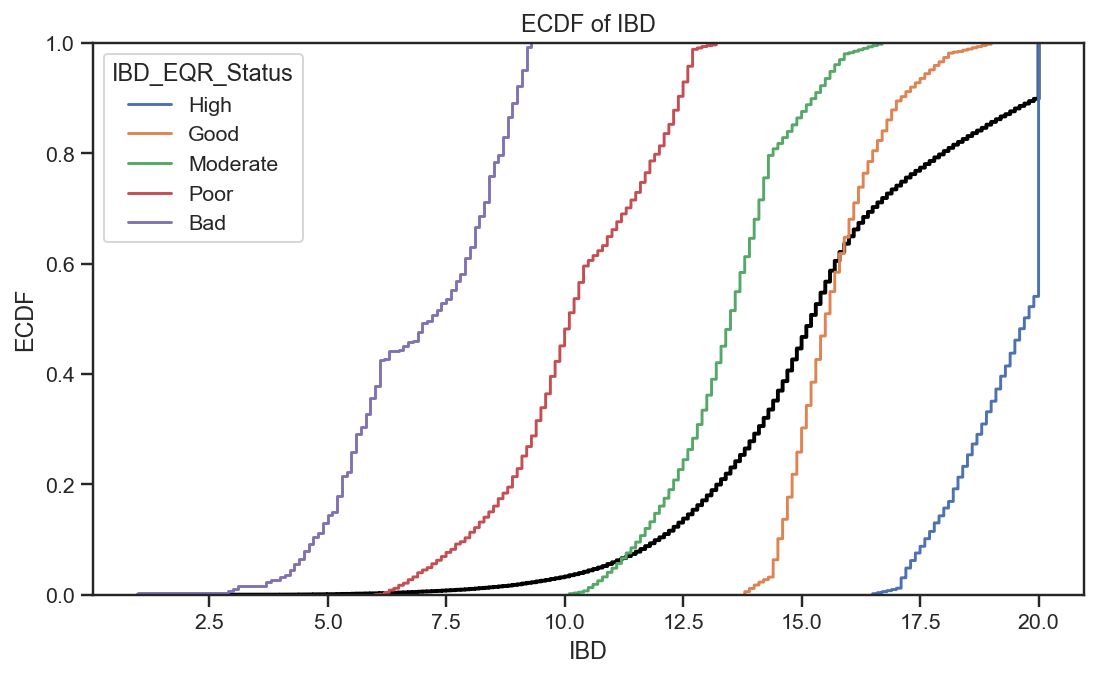

In [46]:
plt.figure(figsize=(8, 5))
sns.ecdfplot(data=df, x="IBD", linewidth=2, color='black')
if "IBD_EQR_Status" in df:
    sns.ecdfplot(data=df, x="IBD", hue="IBD_EQR_Status", hue_order=status_order)
plt.title("ECDF of IBD")
plt.xlabel("IBD")
plt.ylabel("ECDF")
plt.tight_layout()

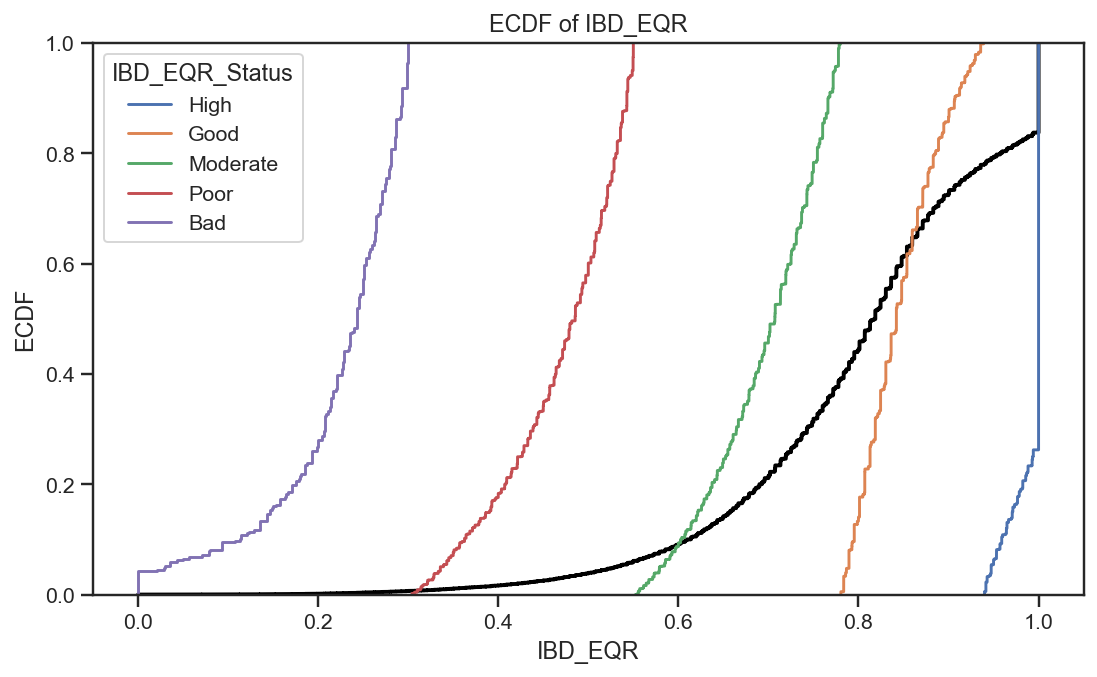

In [47]:
plt.figure(figsize=(8, 5))
sns.ecdfplot(data=df, x="IBD_EQR", linewidth=2, color='black')
if "IBD_EQR_Status" in df:
    sns.ecdfplot(data=df, x="IBD_EQR", hue="IBD_EQR_Status", hue_order=status_order)
plt.title("ECDF of IBD_EQR")
plt.xlabel("IBD_EQR")
plt.ylabel("ECDF")
plt.tight_layout()

In [48]:
# CELL 0 — Imports and setup
import numpy as np, pandas as pd
import seaborn as sns, matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 140
sns.set_theme(context="notebook", style="whitegrid")

# optional extras
try:
    import plotly.express as px
except Exception:
    px = None

# canonical status order
STATUS_ORDER = ["Bad","Poor","Moderate","Good","High"]

# helper: parse date and site from 'SamplingOperations_code' like 'S04319000_20130724'
def enrich(df):
    df = df.copy()
    df["IBD_EQR_Status"] = pd.Categorical(df["IBD_EQR_Status"], categories=STATUS_ORDER, ordered=True)
    df["date"] = pd.to_datetime(df["SamplingOperations_code"].str.extract(r"(\d{8})$", expand=False),
                                format="%Y%m%d", errors="coerce")
    df["year"] = df["date"].dt.year
    df["site"] = df["SamplingOperations_code"].str.extract(r"^(.*)_(\d{8})$", expand=True)[0]
    return df

dfX = enrich(df)
dfX


,SamplingOperations_code,IBD,IBD_EQR,IBD_EQR_Status,date,year,site
0,S04319000_20130724,5.2,0.256098,Bad,2013-07-24,2013,S04319000
1,S06172100_20080716,6.1,0.298246,Bad,2008-07-16,2008,S06172100
2,S03255920_20120802,3.7,0.157895,Bad,2012-08-02,2012,S03255920
3,S04064720_20150710,4.9,0.228070,Bad,2015-07-10,2015,S04064720
4,S05001500_20080726,5.3,0.251462,Bad,2008-07-26,2008,S05001500
...,...,...,...,...,...,...,...
43778,S06165700_20230628,6.8,0.339181,Poor,2023-06-28,2023,S06165700
43779,S06440770_20230524,15.3,0.836257,Good,2023-05-24,2023,S06440770
43780,S06710030_20230627,18.4,1.000000,High,2023-06-27,2023,S06710030
43781,S06036970_20230628,14.5,0.678571,Moderate,2023-06-28,2023,S06036970


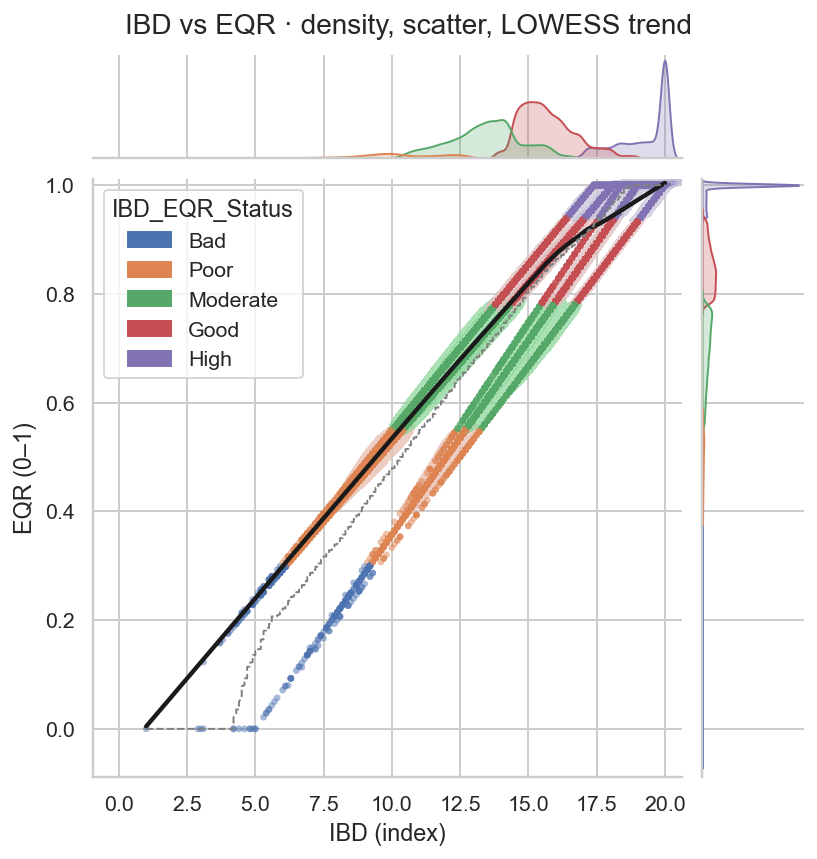

In [49]:
# Joint distribution IBD vs EQR with LOWESS, contours, and monotonic reference
g = sns.jointplot(
    data=dfX, x="IBD", y="IBD_EQR", hue="IBD_EQR_Status",
    kind="kde", fill=True, thresh=0.02, levels=10, height=6, alpha=0.75
)
# overlay scatter (thin)
sns.scatterplot(data=dfX, x="IBD", y="IBD_EQR", hue="IBD_EQR_Status",
                palette=sns.color_palette(n_colors=dfX["IBD_EQR_Status"].nunique()),
                s=12, linewidth=0, legend=False, ax=g.ax_joint, alpha=0.5)
# LOWESS trend
sns.regplot(data=dfX, x="IBD", y="IBD_EQR", lowess=True, scatter=False, color="k", ax=g.ax_joint)
# monotone reference (rank-normalized)
rIBD = dfX["IBD"].rank(pct=True)
rEQR = dfX["IBD_EQR"].rank(pct=True)
g.ax_joint.plot(np.sort(dfX["IBD"]), np.sort(dfX["IBD_EQR"]), ls="--", lw=1, c="gray")
g.set_axis_labels("IBD (index)", "EQR (0–1)")
plt.suptitle("IBD vs EQR · density, scatter, LOWESS trend", y=1.02)
plt.show()


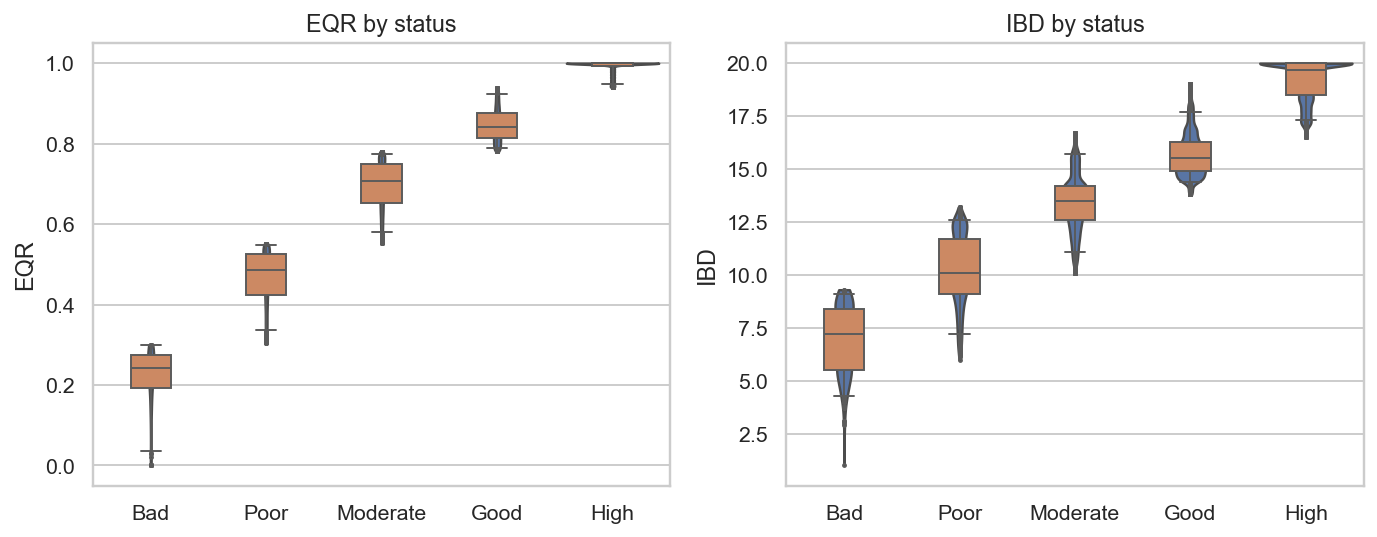

In [ ]:
# Violin+box paired panels: EQR and IBD by Status (ordered)
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=False)
sns.violinplot(data=dfX, x="IBD_EQR_Status", y="IBD_EQR", inner=None, cut=0, ax=axes[0])
sns.boxplot(data=dfX, x="IBD_EQR_Status", y="IBD_EQR", whis=(5,95), width=0.35, fliersize=1.5, ax=axes[0])
axes[0].set_title("EQR by status"); axes[0].set_xlabel(""); axes[0].set_ylabel("EQR")

sns.violinplot(data=dfX, x="IBD_EQR_Status", y="IBD", inner=None, cut=0, ax=axes[1])
sns.boxplot(data=dfX, x="IBD_EQR_Status", y="IBD", whis=(5,95), width=0.35, fliersize=1.5, ax=axes[1])
axes[1].set_title("IBD by status"); axes[1].set_xlabel(""); axes[1].set_ylabel("IBD")
plt.tight_layout(); plt.show()


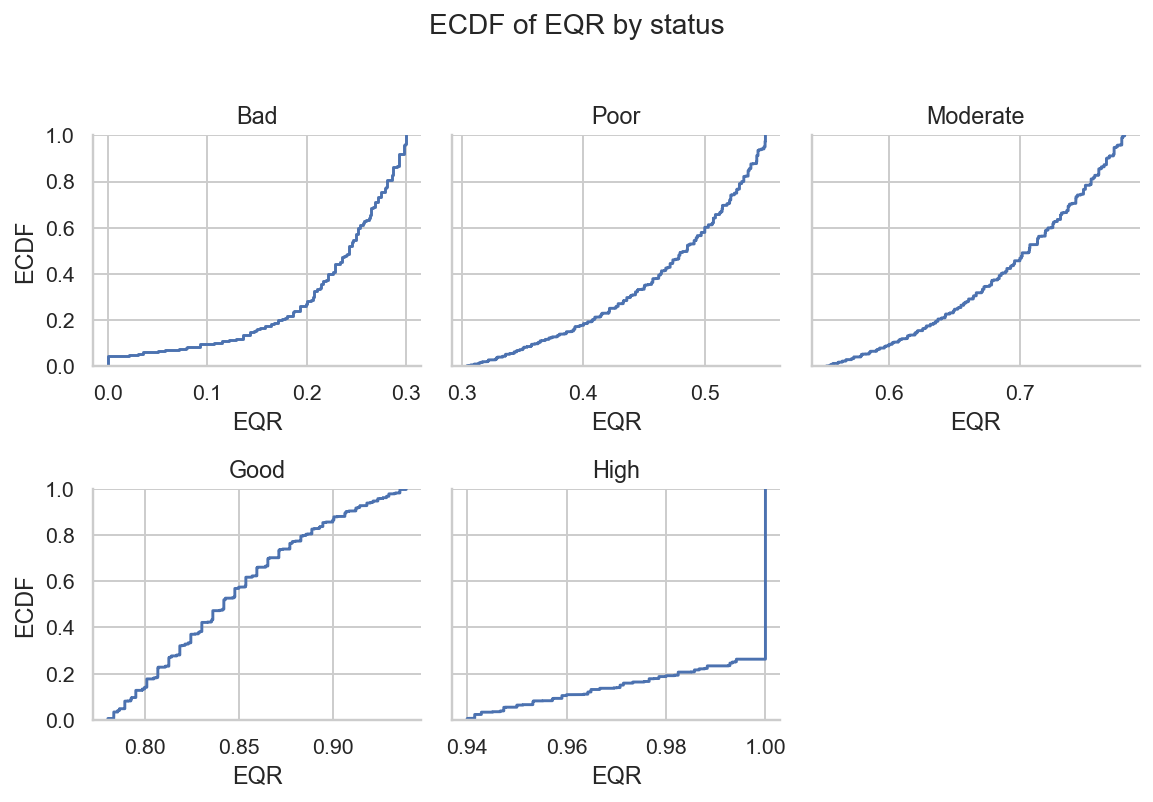

In [ ]:
# ECDFs to compare full distributions across statuses
g = sns.FacetGrid(dfX, col="IBD_EQR_Status", col_wrap=3, sharex=False, height=2.8)
g.map(sns.ecdfplot, "IBD_EQR").set_titles("{col_name}")
for ax in g.axes.ravel():
    ax.set_xlabel("EQR"); ax.set_ylabel("ECDF")
plt.suptitle("ECDF of EQR by status", y=1.02); plt.tight_layout(); plt.show()


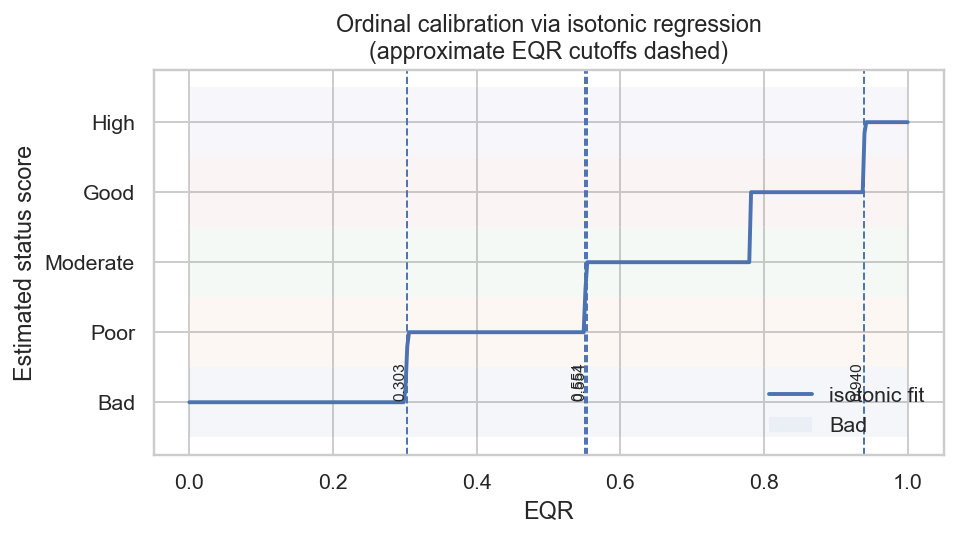

{1.5: np.float64(0.3032581453634085),
 2.5: np.float64(0.5513784461152882),
 3.5: np.float64(0.5538847117794485),
 4.5: np.float64(0.9398496240601504)}

In [ ]:
# Ordinal calibration: Isotonic regression EQR→Status score, infer thresholds
# maps EQR ∈ [0,1] to an ordinal score y∈{1,...,5} corresponding to statuses
from sklearn.isotonic import IsotonicRegression

y_ord = dfX["IBD_EQR_Status"].cat.codes + 1  # 1..5
x = dfX["IBD_EQR"].to_numpy()
iso = IsotonicRegression(out_of_bounds="clip").fit(x, y_ord)

xx = np.linspace(np.nanmin(x), np.nanmax(x), 400)
yy = iso.predict(xx)

plt.figure(figsize=(7,4))
plt.plot(xx, yy, lw=2, label="isotonic fit")
# horizontal bands for integer categories
for k,(lo,hi,name) in enumerate(zip([0,1,2,3,4],[1,2,3,4,5], STATUS_ORDER), start=1):
    plt.fill_between(xx, lo+0.5, hi+0.5, alpha=0.06, label=name if k==1 else None)
# estimated EQR cutoffs where fit crosses 1.5,2.5,3.5,4.5
cuts = {}
for t in [1.5,2.5,3.5,4.5]:
    i = np.argmin(np.abs(yy - t))
    cuts[t] = xx[i]
for t,xcut in cuts.items():
    plt.axvline(xcut, ls="--", lw=1)
    plt.text(xcut, 1.02, f"{xcut:.3f}", rotation=90, va="bottom", ha="right", fontsize=8)

plt.yticks([1,2,3,4,5], STATUS_ORDER)
plt.xlabel("EQR"); plt.ylabel("Estimated status score")
plt.title("Ordinal calibration via isotonic regression\n(approximate EQR cutoffs dashed)")
plt.legend(frameon=False, loc="lower right")
plt.tight_layout(); plt.show()

cuts  # dict of approximate thresholds


C:\Users\herie\AppData\Local\Temp\ipykernel_15312\3603373332.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\herie\AppData\Local\Temp\ipykernel_15312\3603373332.py:10: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



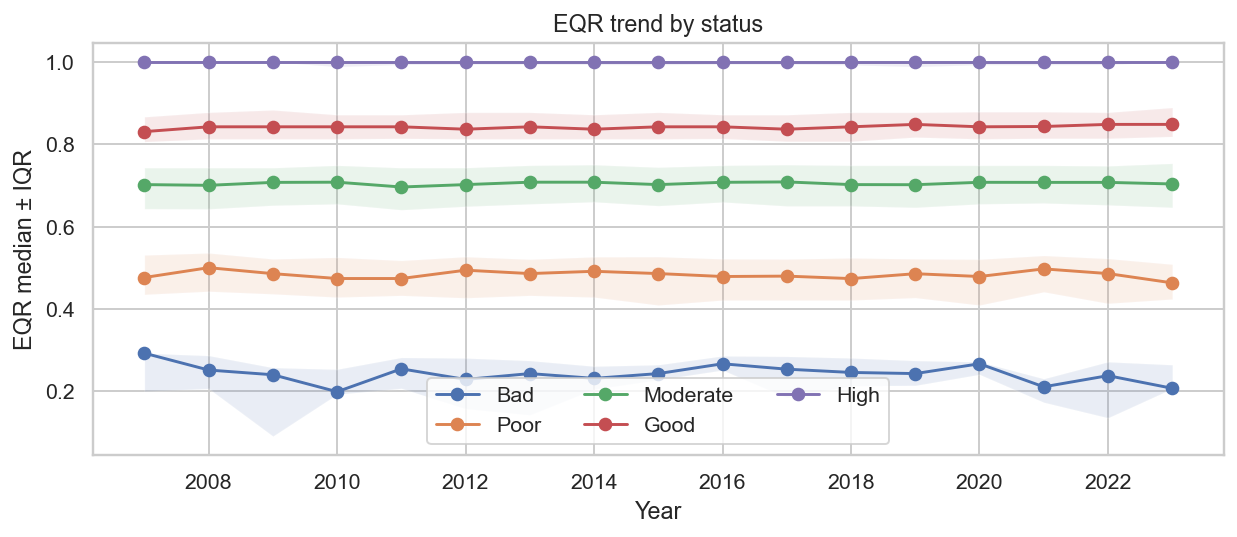

In [ ]:
# Temporal structure: yearly medians with uncertainty ribbons
agg = (dfX.dropna(subset=["year"])
          .groupby(["year","IBD_EQR_Status"])
          .agg(EQR_med=("IBD_EQR","median"),
               EQR_q25=("IBD_EQR",lambda s: s.quantile(0.25)),
               EQR_q75=("IBD_EQR",lambda s: s.quantile(0.75)),
               n=("IBD_EQR","size"))
          .reset_index())
plt.figure(figsize=(9,4))
for s,grp in agg.groupby("IBD_EQR_Status"):
    plt.plot(grp["year"], grp["EQR_med"], marker="o", label=s, lw=1.5)
    plt.fill_between(grp["year"], grp["EQR_q25"], grp["EQR_q75"], alpha=0.12)
plt.xlabel("Year"); plt.ylabel("EQR median ± IQR"); plt.title("EQR trend by status"); plt.legend(ncol=3)
plt.tight_layout(); plt.show()


C:\Users\herie\AppData\Local\Temp\ipykernel_15312\3349451636.py:4: UserWarning:



The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.




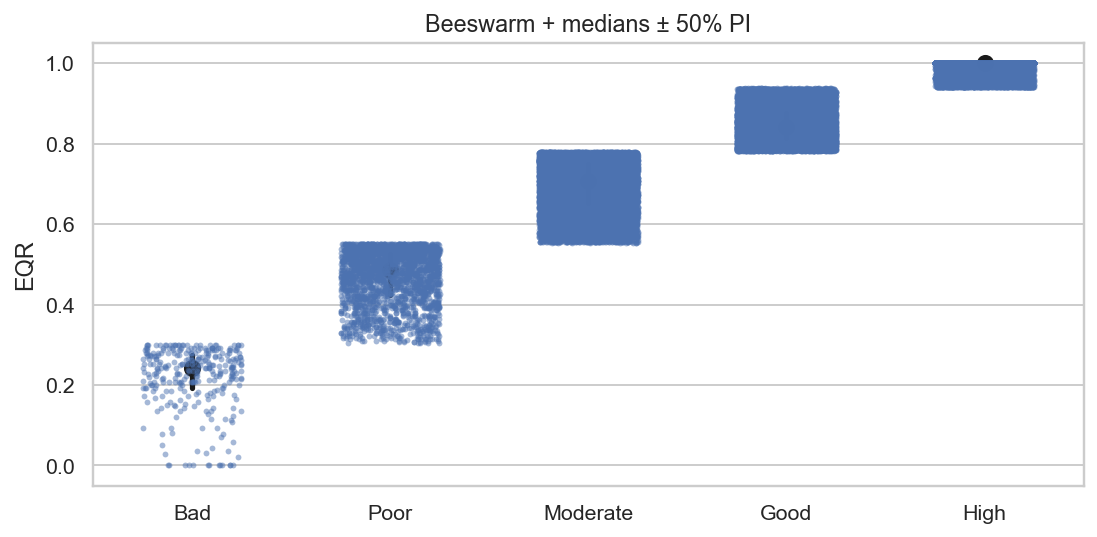

In [ ]:
# Beeswarm for EQR with layered summary stats
plt.figure(figsize=(8,4))
sns.stripplot(data=dfX, x="IBD_EQR_Status", y="IBD_EQR", jitter=0.25, alpha=0.5, size=3)
sns.pointplot(data=dfX, x="IBD_EQR_Status", y="IBD_EQR", estimator="median",
              errorbar=("pi", 50), join=False, color="k")
plt.xlabel(""); plt.ylabel("EQR"); plt.title("Beeswarm + medians ± 50% PI"); plt.tight_layout(); plt.show()


In [ ]:
# Interactive alternative (if Plotly available): EQR vs IBD colored by Status
if px is not None:
    fig = px.scatter(dfX, x="IBD", y="IBD_EQR", color="IBD_EQR_Status",
                     hover_data=["SamplingOperations_code","site","year"],
                     trendline="lowess", trendline_options=dict(frac=0.3))
    fig.update_layout(title="IBD vs EQR with LOWESS", xaxis_title="IBD", yaxis_title="EQR")
    fig.show()
else:
    print("Plotly not available; skip CELL 9 or install plotly.")


c:\Users\herie\miniconda3\envs\u\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning:

invalid value encountered in divide



In [ ]:
# Sanity table: summary by status
summary = (dfX.groupby("IBD_EQR_Status")
             .agg(n=("IBD_EQR","size"),
                  EQR_med=("IBD_EQR","median"),
                  EQR_iqr=("IBD_EQR", lambda s: s.quantile(0.75)-s.quantile(0.25)),
                  IBD_med=("IBD","median"))
             .reindex(STATUS_ORDER))
summary


C:\Users\herie\AppData\Local\Temp\ipykernel_15312\1477146527.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,n,EQR_med,EQR_iqr,IBD_med
IBD_EQR_Status,,,,
Bad,306,0.242857,0.081871,7.2
Poor,2383,0.485380,0.102915,10.1
Moderate,14396,0.707143,0.096099,13.5
Good,17061,0.842105,0.064327,15.5
High,9637,1.000000,0.006667,19.7
